In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import joblib
from scipy import stats
from scipy.stats import chi2_contingency
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, MinMaxScaler, OrdinalEncoder

In [2]:
# Chargement du Dataset néttoyé
df = pd.read_csv("./data/train_clean.csv")

In [3]:
# Statistiques descriptives des variables numériques
df.describe()

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance
count,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,1.000000e+05
mean,34.334430,5.145607e+04,4198.490149,5.410915,5.600860,72.466040,3.418990,21.06828,13.560240,5.996180,1426.220376,32.285173,221.111580,119.193120,617.257610,-3.000000e+22
std,9.858117,1.345878e+05,3187.491752,5.947716,7.104814,466.422621,4.213839,14.78723,27.289878,17.885484,1155.129026,5.116875,99.668748,815.211289,1999.677146,3.162151e+24
min,18.000000,7.005930e+03,303.645417,0.000000,0.000000,1.000000,-100.000000,-5.00000,-3.000000,0.000000,0.230000,20.000000,1.000000,0.000000,0.000000,-3.333333e+26
25%,26.000000,1.934297e+04,1626.761667,3.000000,4.000000,8.000000,2.000000,10.00000,9.000000,3.000000,566.072500,28.052567,144.000000,29.268886,75.356284,2.703078e+02
50%,34.000000,3.700258e+04,3095.978333,5.000000,5.000000,13.000000,3.000000,18.00000,14.000000,5.000000,1166.155000,32.305784,219.000000,66.506180,136.173912,3.372525e+02
75%,42.000000,7.168968e+04,5961.637500,7.000000,7.000000,20.000000,5.000000,28.00000,18.000000,8.000000,1945.962500,36.496663,302.000000,147.392573,263.231662,4.719186e+02
max,56.000000,2.193619e+07,15204.633333,955.000000,1196.000000,5797.000000,9.000000,67.00000,4281.000000,2081.000000,4998.070000,50.000000,404.000000,79756.000000,10000.000000,1.602041e+03


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 24 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Name                      100000 non-null  object 
 1   Age                       100000 non-null  float64
 2   SSN                       100000 non-null  object 
 3   Occupation                100000 non-null  object 
 4   Annual_Income             100000 non-null  float64
 5   Monthly_Inhand_Salary     100000 non-null  float64
 6   Num_Bank_Accounts         100000 non-null  float64
 7   Num_Credit_Card           100000 non-null  float64
 8   Interest_Rate             100000 non-null  int64  
 9   Num_of_Loan               100000 non-null  float64
 10  Delay_from_due_date       100000 non-null  float64
 11  Num_of_Delayed_Payment    100000 non-null  float64
 12  Changed_Credit_Limit      100000 non-null  object 
 13  Num_Credit_Inquiries      100000 non-null  fl

#
# 18. Histogramme + kde du Annual Income selon le Crédit Score

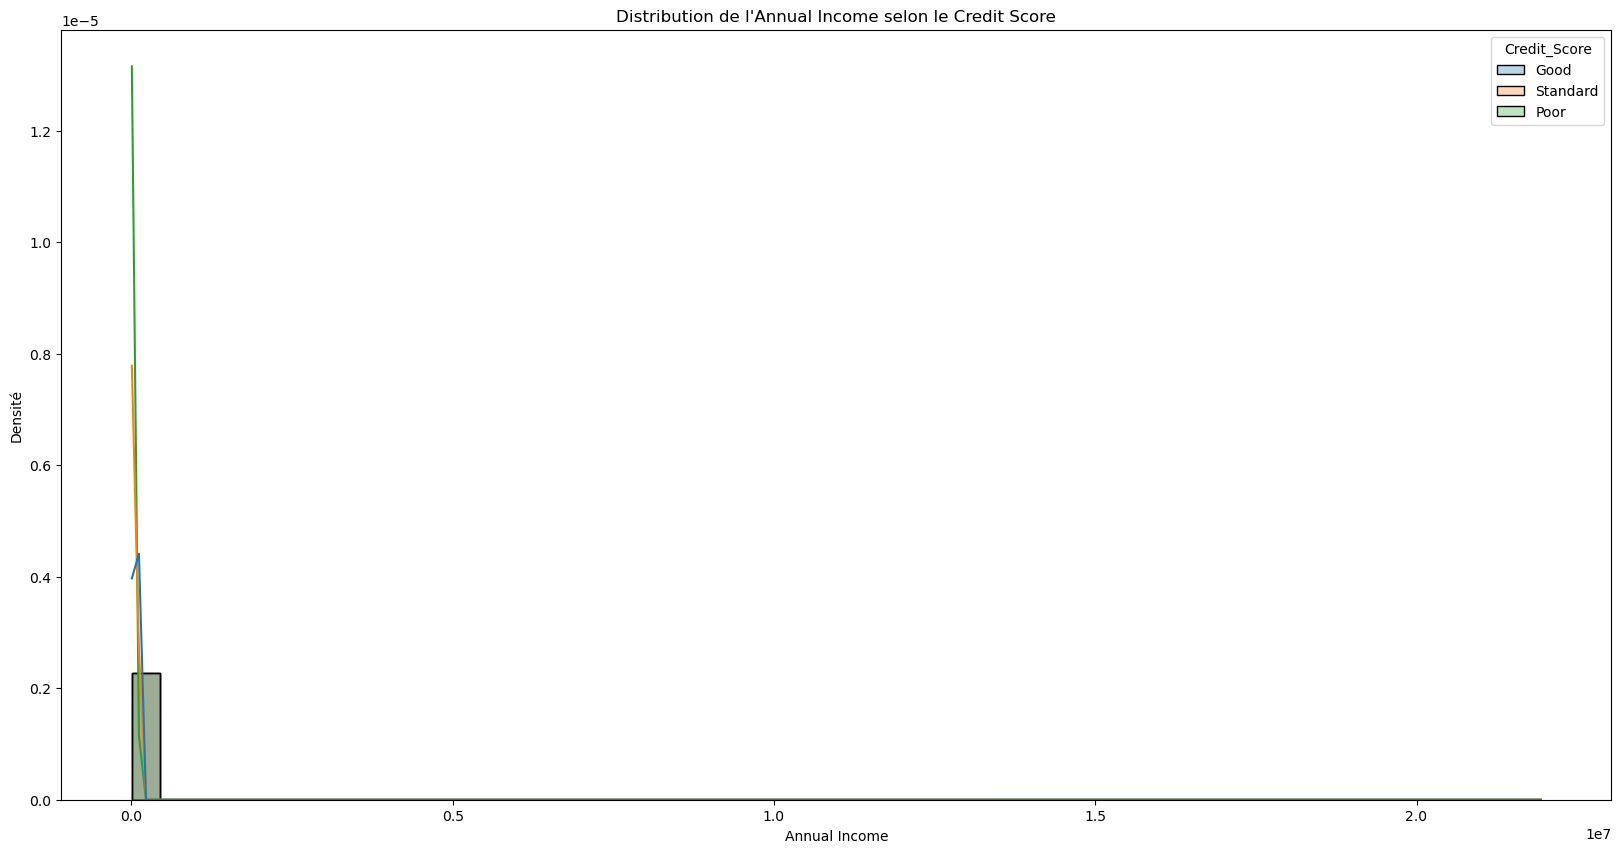

In [5]:
plt.figure(figsize=(20,10))

sns.histplot(
    data=df,
    x="Annual_Income",
    bins=50,
    hue = "Credit_Score",
    kde = True,
    stat="density",
    common_norm=False,
    alpha=0.3,
) #On affiche la densité en ordonées pour avoir l'histogramme et les Kde sur une meme échèle, common_norm = False pour une normalisation indépendante

plt.title("Distribution de l'Annual Income selon le Credit Score")
plt.xlabel("Annual Income")
plt.ylabel("Densité")
plt.show()

plt.tight_layout()
plt.savefig("figures/18 Historigramme_Annual_Income.png") # Sauegarde de la figure dans le dossiers "figures"
plt.close()

#
# 19. Boxplots de Delay_From_due_date et de Outsatnding_debt selon Credit_score

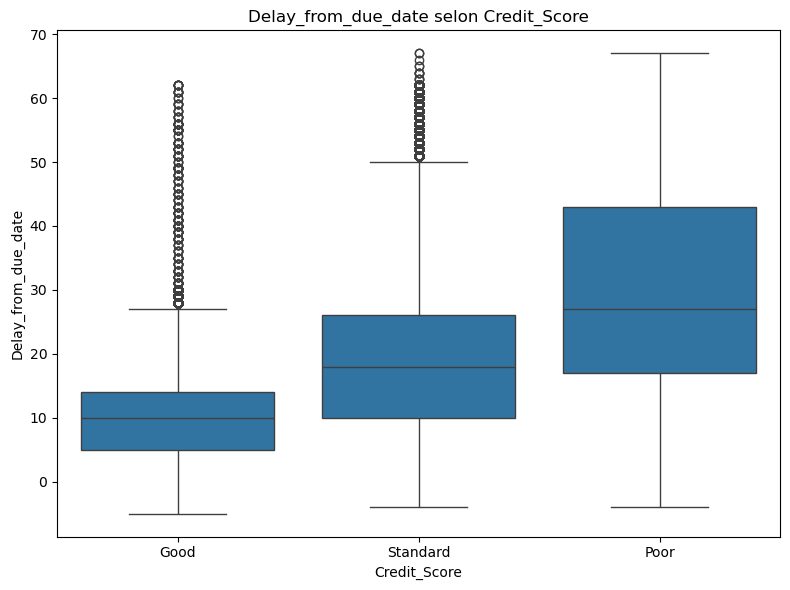

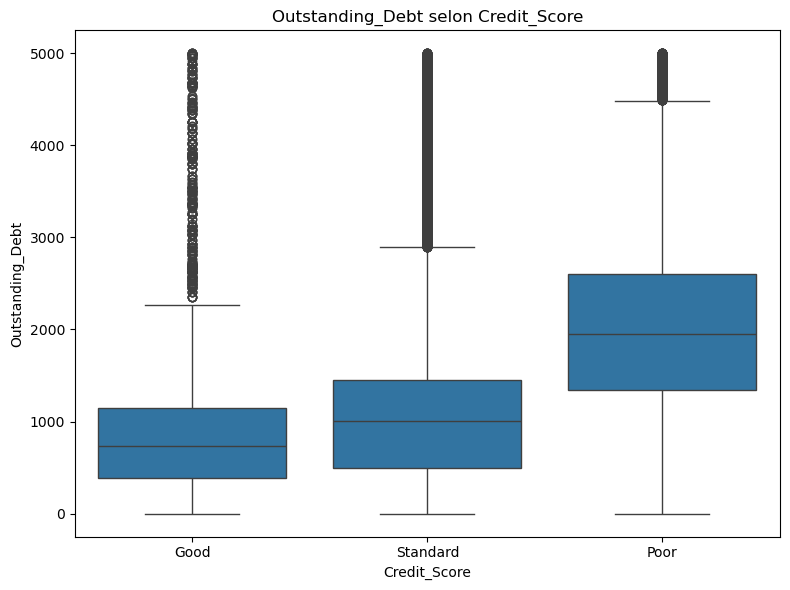

In [6]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df, x="Credit_Score", y="Delay_from_due_date")
plt.title("Delay_from_due_date selon Credit_Score")
plt.tight_layout()
plt.savefig("figures/19.1 Boxplot_Delay_from_due_date.png") # Sauvegarde
plt.show()

plt.figure(figsize=(8,6))
sns.boxplot(data=df, x="Credit_Score", y="Outstanding_Debt")
plt.title("Outstanding_Debt selon Credit_Score")
plt.tight_layout()
plt.savefig("figures/19.2 Boxplot_Outstanding_debt.png")
plt.show()

In [7]:
encoder = OrdinalEncoder(categories=[["Poor","Standard","Good"]])

df["Credit_Score"] = encoder.fit_transform(df[["Credit_Score"]]) # GOOD : 2 et STANDARD : 1

df["Credit_Score"].head(10)

0    2.0
1    2.0
2    2.0
3    2.0
4    2.0
5    2.0
6    2.0
7    1.0
8    1.0
9    2.0
Name: Credit_Score, dtype: float64

#
# 20. Heatmap de corrélation entre toutes les variables numériques

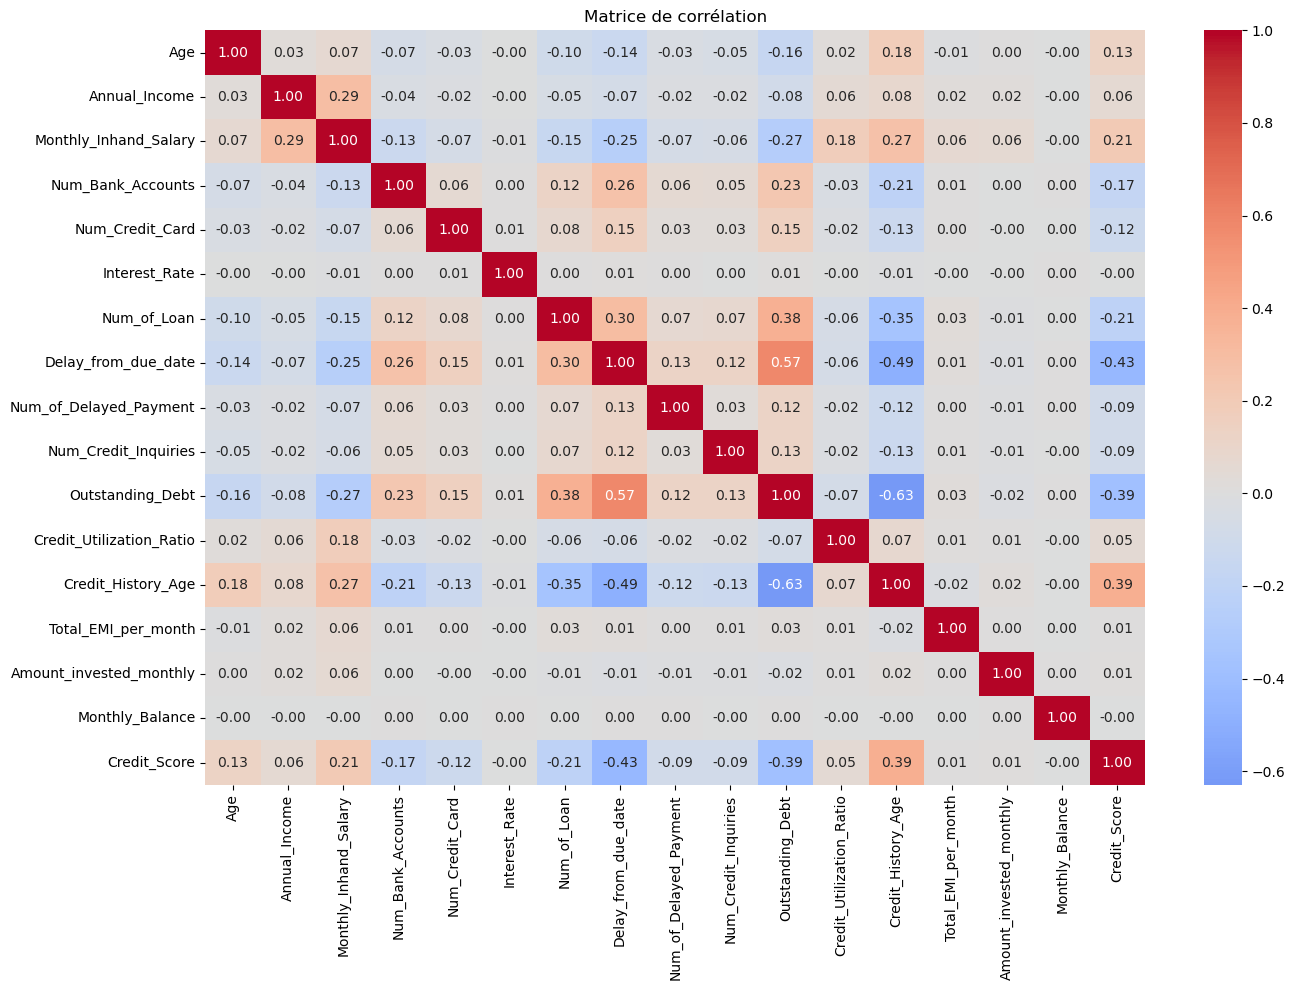

In [8]:
numeric_df = df.select_dtypes(include=np.number) #Selection des variables nuériques pour le Heatmap

corr_matrix = numeric_df.corr() # création de la matrice de corrélation

plt.figure(figsize=(14,10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("Matrice de corrélation")
plt.tight_layout()
plt.savefig("figures/Heatmap_Correlation.png") # Sauvegarde dans le dossier "figures"
plt.show()

# 
# Analyse des corrélations

## Les trois corrélations les plus fortes

### D'après cette heatmap, les corrélations les plus marquées sont :

1. **Outstanding_Debt** et **Credit_History_Age** avec un coefficient de **-0.63** :  
   Cette corrélation négative modérée indique qu'une ancienneté plus importante de l'historique de crédit est généralement associée à un niveau de dette en cours plus faible.

2. **Outstanding_Debt** et **Delay_from_Due_Date** avec un coefficient de **0.57** :  
   Cette corrélation positive modérée suggère qu'une augmentation de la dette en cours tend à s'accompagner d'un plus grand nombre de jours de retard de paiement.

3. **Credit_History_Age** et **Delay_from_Due_Date** avec un coefficient de **-0.49** :  
   Cette corrélation négative modérée indique que les clients disposant d'un historique de crédit plus ancien ont tendance à accumuler moins de retards de paiement.

#
#  21. Scarterplot Annual_Income vs Outstanding_Debt selon Credit_Score

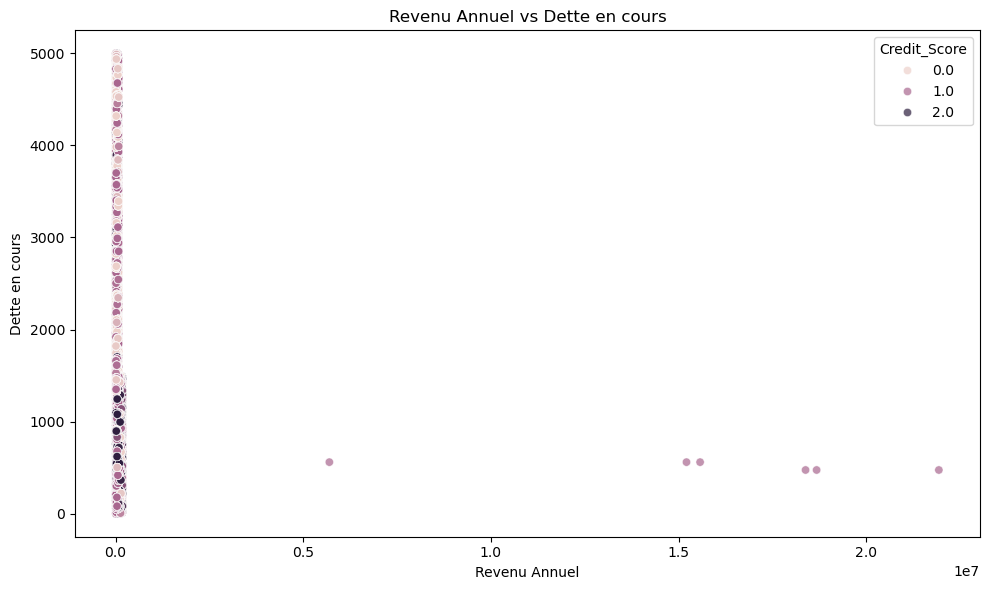

In [9]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="Annual_Income",
    y="Outstanding_Debt",
    hue="Credit_Score",
    alpha=0.7
)

plt.title("Revenu Annuel vs Dette en cours")
plt.xlabel("Revenu Annuel")
plt.ylabel("Dette en cours")
plt.tight_layout()
plt.savefig("figures/ScatterPlot_Revenue_Annuel_vs_Dette_en_cours.png") # Sauvegarde dans le dossier "figures"
plt.show()


#
# 22. Barplot de la répartion du Score de Crédit selon le comportement de paiement

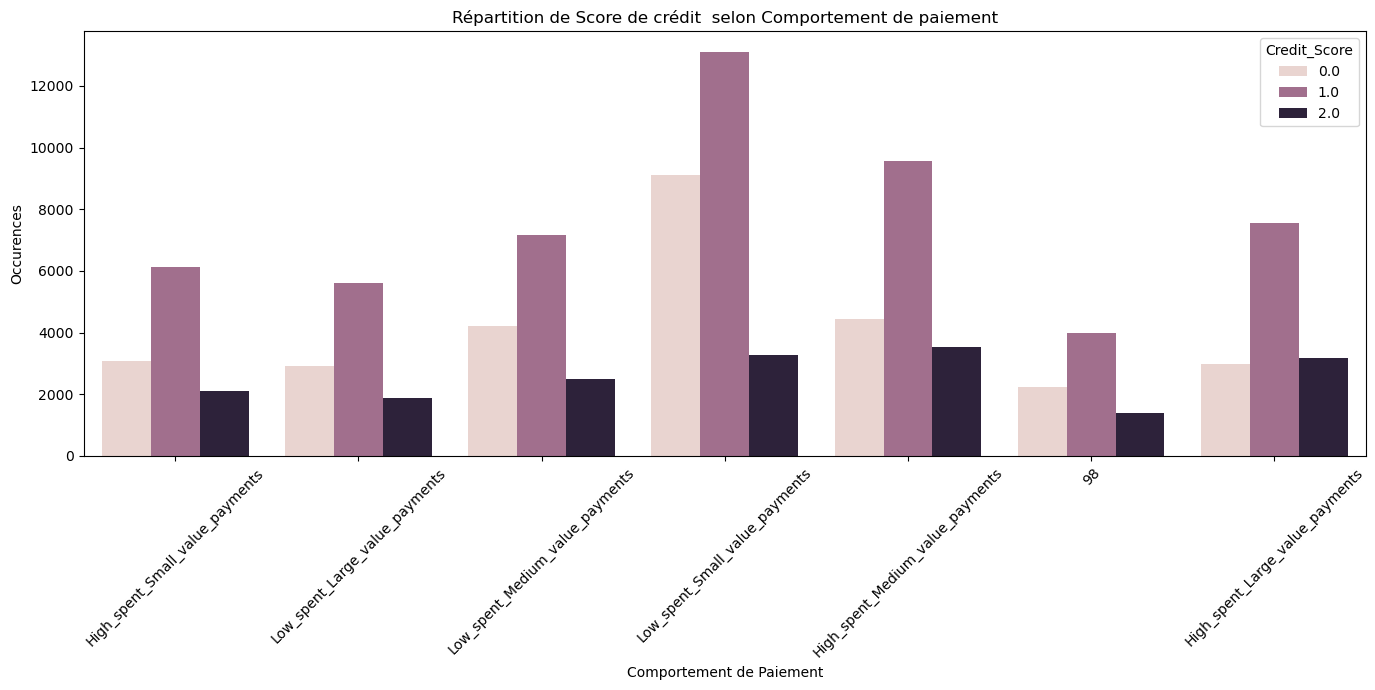

In [10]:
plt.figure(figsize=(14,7))

sns.countplot(
    data=df,
    x="Payment_Behaviour",
    hue="Credit_Score"
)

plt.xticks(rotation=45)
plt.title("Répartition de Score de crédit  selon Comportement de paiement")
plt.xlabel("Comportement de Paiement")
plt.ylabel("Occurences")
plt.tight_layout()
plt.savefig("figures/Barplot.png") # Sauvegarde dans le dossier "figures"
plt.show()

#
# 23. Test du Chi 2 entre Comportement de paiement du montant minimun et Crédit Score

In [11]:
table = pd.crosstab(
    df["Payment_of_Min_Amount"],
    df["Credit_Score"]
)

chi2, p_value, dof, expected = chi2_contingency(table)

print(f"Chi² = {chi2:.4f}")
print(f"p-value = {p_value:.6f}")

alpha = 0.05

if p_value < alpha:
    print("Conclusion : rejet de H0 (variables dépendantes).")
else:
    print("Conclusion : on ne rejette pas H0 (variables indépendantes).")

Chi² = 19620.3948
p-value = 0.000000
Conclusion : rejet de H0 (variables dépendantes).
